In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
df= pd.read_csv('loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
ncols= df.select_dtypes(include=['int64', 'float64']).columns
for col in ncols:
    df[col].fillna(df[col].median(), inplace= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_25252\691363344.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace= True)


In [10]:
cols= df.select_dtypes(include= 'object').columns
for col in cols:
    df[col].fillna(df[col].mode()[0], inplace= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_25252\3941993004.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace= True)


In [11]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## EDA

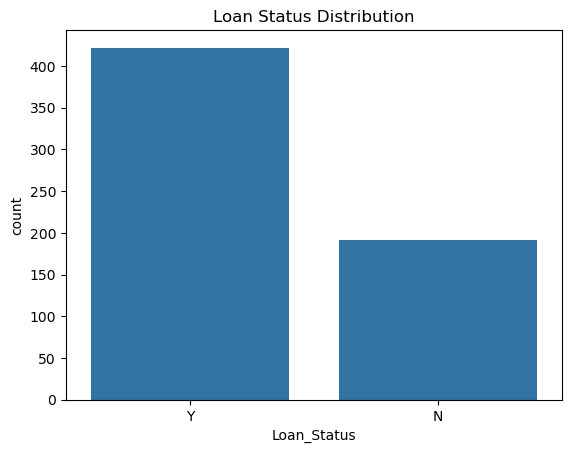

In [12]:
sns.countplot(x= 'Loan_Status', data= df)
plt.title('Loan Status Distribution')
plt.show()

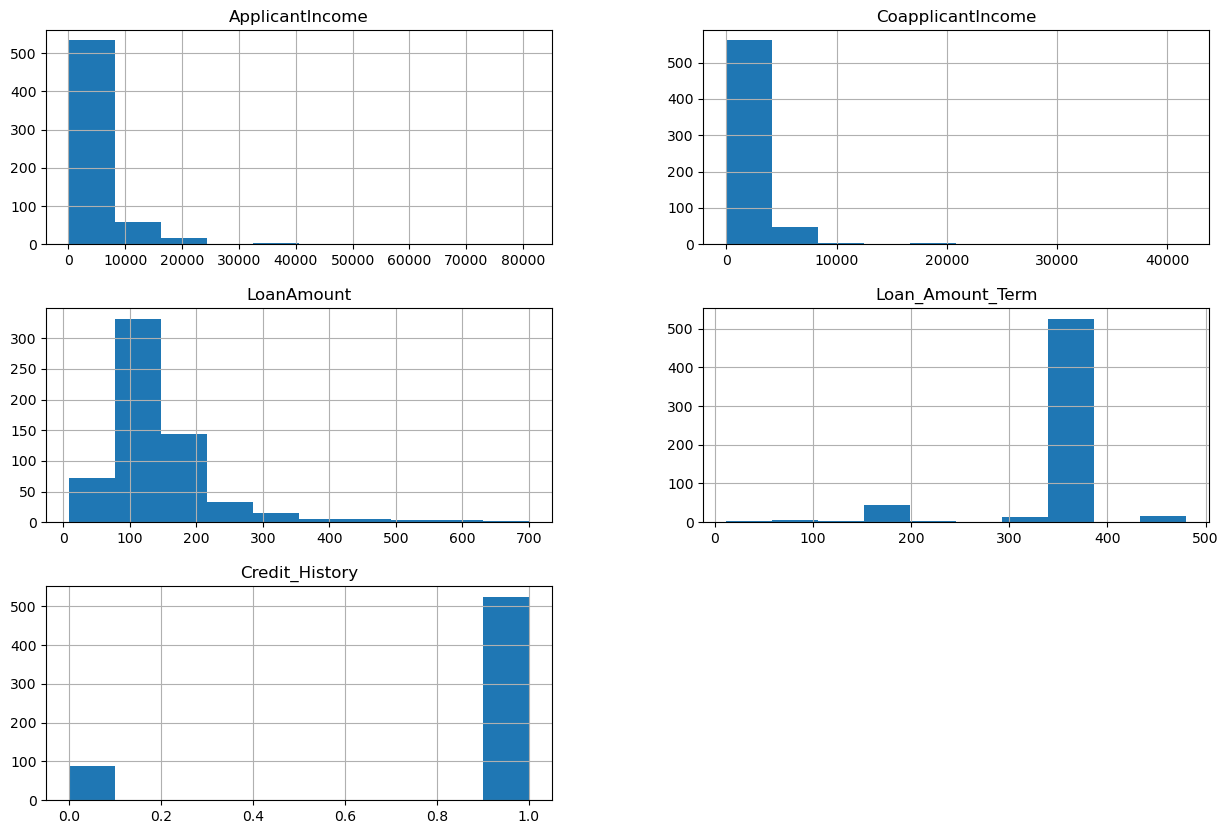

In [13]:
df.hist(figsize=(15,10))
plt.show()

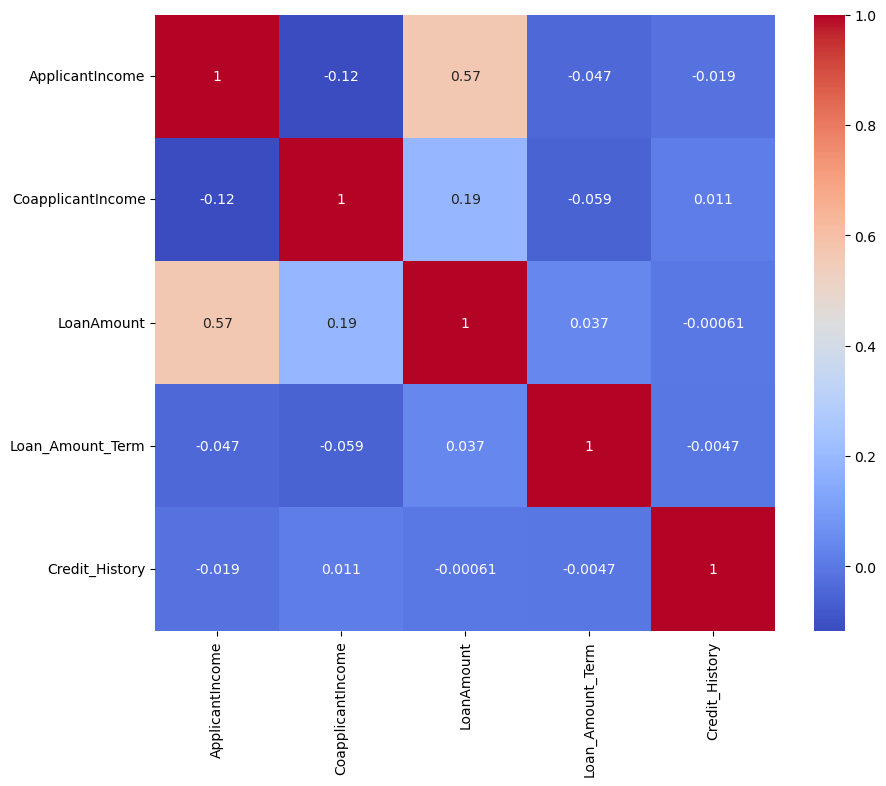

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only= True), annot= True, cmap= 'coolwarm')
plt.show()

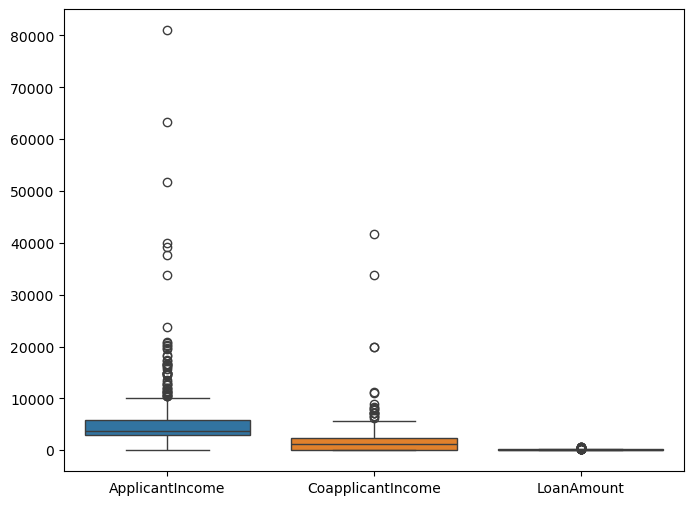

In [15]:
plt.figure(figsize= (8,6))

sns.boxplot(data= df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']])
plt.show()

In [16]:
Q1= df['LoanAmount'].quantile(0.25)
Q3= df['LoanAmount'].quantile(0.75)

IQR= Q3-Q1

lower= Q1-1.5*IQR
upper= Q3+1.5*IQR

df= df[(df['LoanAmount'] >=lower) & (df['LoanAmount'] <= upper)]

## Encode Categorical Variables

In [17]:
le= LabelEncoder()
for col in cols:
    df[col]= le.fit_transform(df[col])

## Feature Engineering

In [18]:
# Total Income
df['TotalIncome']= df['ApplicantIncome'] + df['CoapplicantIncome']

# Income per Loan
df['IncomeLoanRatio']= df['TotalIncome']/df['LoanAmount']

# Loan per Income
df['LoanIncomeRatio']= df['LoanAmount']/df['TotalIncome']

# log Income
df['LogIncome']= np.log(df['TotalIncome'])

In [19]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeLoanRatio,LoanIncomeRatio,LogIncome
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,45.695312,0.021884,8.674026
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,47.585938,0.021015,8.714568
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,45.454545,0.022000,8.006368
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,41.175000,0.024287,8.505323
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,42.553191,0.023500,8.699515


In [20]:
x= df.drop('Loan_Status', axis= 1)
y= df['Loan_Status']

In [21]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 42, stratify= y)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.fit_transform(x_test)

## Model Training and Evaluation

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, f1_score, recall_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)

from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

In [24]:
print(y_train.value_counts())

Loan_Status
1    317
0    141
Name: count, dtype: int64


In [25]:
smote= SMOTE(random_state= 42)

x_train_smote, y_train_smote= smote.fit_resample(x_train,y_train)

In [26]:
print(y_train_smote.value_counts())

Loan_Status
0    317
1    317
Name: count, dtype: int64


## Building multiple models

In [27]:
models= {
    'lr': LogisticRegression(max_iter= 1000),
    'dt': DecisionTreeClassifier(random_state= 42),
    'rf': RandomForestClassifier(random_state= 42),
    'xgb': XGBClassifier(random_state= 42, eval_metric= 'logloss')
} 

In [28]:
results= []
for name, model in models.items():
    model.fit(x_train_smote, y_train_smote)
    predictions= model.predict(x_test)
    probabilities= model.predict_proba(x_test)[:,1]
    accuracy= accuracy_score(y_test, predictions)
    precision= precision_score(y_test, predictions)
    recall= recall_score(y_test, predictions)
    f1= f1_score(y_test, predictions)
    roc= roc_auc_score(y_test, probabilities)
    results.append([name, accuracy, precision, recall, f1, roc])

    print('='*10)
    print(name)
    print(classification_report(y_test,predictions))

lr
              precision    recall  f1-score   support

           0       0.74      0.57      0.65        35
           1       0.83      0.91      0.87        80

    accuracy                           0.81       115
   macro avg       0.79      0.74      0.76       115
weighted avg       0.80      0.81      0.80       115

dt
              precision    recall  f1-score   support

           0       0.45      0.63      0.52        35
           1       0.80      0.66      0.73        80

    accuracy                           0.65       115
   macro avg       0.63      0.65      0.62       115
weighted avg       0.70      0.65      0.66       115

rf
              precision    recall  f1-score   support

           0       0.57      0.60      0.58        35
           1       0.82      0.80      0.81        80

    accuracy                           0.74       115
   macro avg       0.69      0.70      0.70       115
weighted avg       0.74      0.74      0.74       115

xgb
      

In [29]:
results_df= pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
results_df.sort_values(by= 'ROC-AUC', ascending= False, inplace= True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,rf,0.739130,0.820513,0.8000,0.810127,0.750714
3,xgb,0.652174,0.833333,0.6250,0.714286,0.742143
0,lr,0.808696,0.829545,0.9125,0.869048,0.732857
1,dt,0.652174,0.803030,0.6625,0.726027,0.645536


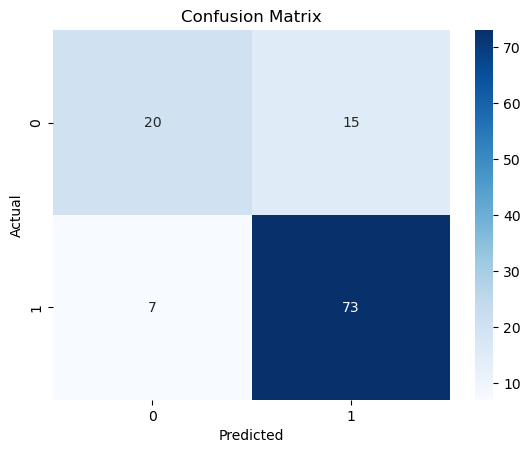

In [31]:
best_model= models['lr']
pred= best_model.predict(x_test)
cm= confusion_matrix(y_test, pred)
sns.heatmap(cm, annot= True, fmt= 'd', cmap= 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
           

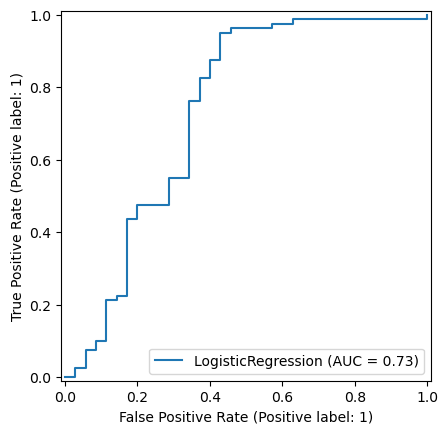

In [32]:
RocCurveDisplay.from_estimator(best_model, x_test,y_test)
plt.show()

## Stratified KFold Cross Validation

In [33]:
cv= StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

In [34]:
scores= cross_val_score(best_model, x_train_smote, y_train_smote,cv= cv, scoring= 'roc_auc')
print(scores)
print(f'Average ROC-AUC: {scores.mean()}')

[0.71106151 0.80555556 0.8077877  0.69642857 0.78483245]
Average ROC-AUC: 0.7611331569664903


## Feature Importance

In [36]:
importance= pd.DataFrame({'Features' : x.columns, 'Importance' : best_model.coef_[0]})
importance= importance.sort_values(by= 'Importance', ascending= False)

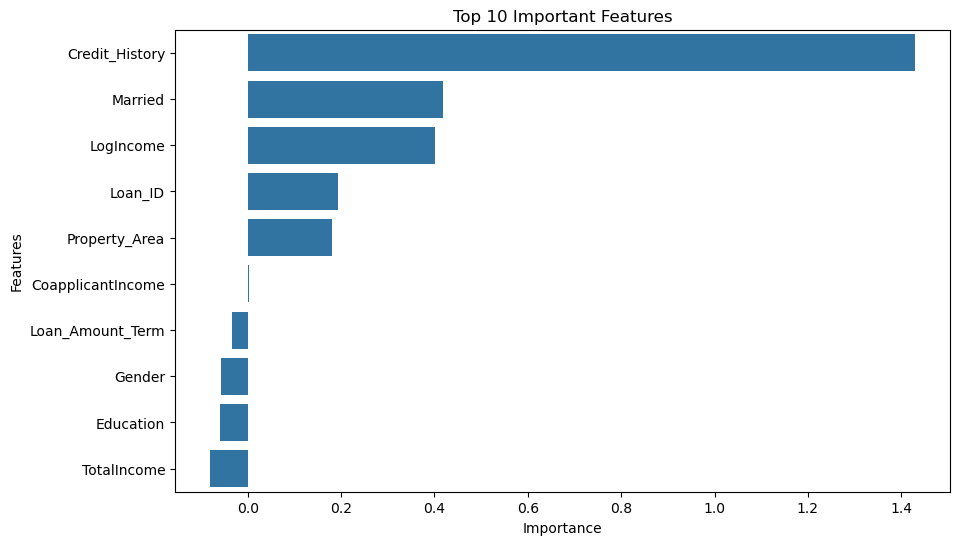

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(data= importance.head(10), x= 'Importance', y= 'Features')
plt.title('Top 10 Important Features')
plt.show()

In [50]:
import joblib

In [52]:
joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']

In [53]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [39]:
from sklearn.model_selection import GridSearchCV

In [41]:
LR= LogisticRegression(random_state= 42)

In [42]:
param_grid= {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

In [43]:
grid= GridSearchCV(estimator= LR, param_grid= param_grid, cv= 5, scoring= 'f1', n_jobs= -1)
grid.fit(x_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='f1')

In [44]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
0.7694809194412168


In [48]:
best_modell= grid.best_estimator_

In [49]:
pred= best_modell.predict(x_test)
prob= best_modell.predict_proba(x_test)[:,1]
print(classification_report(y_test, pred))
print('ROC_AUC:', roc_auc_score(y_test, prob))

              precision    recall  f1-score   support

           0       0.90      0.51      0.65        35
           1       0.82      0.97      0.89        80

    accuracy                           0.83       115
   macro avg       0.86      0.74      0.77       115
weighted avg       0.85      0.83      0.82       115

ROC_AUC: 0.744642857142857


In [54]:
!pip install shap

   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   -- ------------------------------------- 1.0/15.6 MB 6.3 MB/s eta 0:00:03
   ---- ----------------------------------- 1.8/15.6 MB 4.8 MB/s eta 0:00:03
   ------ --------------------------------- 2.6/15.6 MB 4.4 MB/s eta 0:00:03
   --------- ------------------------------ 3.7/15.6 MB 4.3 MB/s eta 0:00:03
   ----------- ---------------------------- 4.5/15.6 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 5.2/15.6 MB 4.1 MB/s eta 0:00:03
   --------------- ------------------------ 6.0/15.6 MB 4.1 MB/s eta 0:00:03
   ----------------- ---------------------- 6.8/15.6 MB 4.1 MB/s eta 0:00:03
   ------------------ --------------------- 7.3/15.6 MB 3.8 MB/s eta 0:00:03
   -------------------- ------------------- 7.9/15.6 MB 3.9 MB/s eta 0:00:03
   --------------------- ------------------ 8.4/15.6 MB 3.7 MB/s eta 0:00:02
   ---------------------- ----------------- 8.9/15.6 MB 3.6 MB/s eta 0:00:02
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [56]:
import numpy as np
import shap

print("NumPy:", np.__version__)
print("SHAP:", shap.__version__)

NumPy: 1.26.4
SHAP: 0.52.0


In [59]:
!pip install numpy==1.26.4

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [61]:
!pip install numpy==1.26.4
!pip install protobuf==5.29.5

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.5 which is incompatible.


In [62]:
print("SHAP:", shap.__version__)

SHAP: 0.52.0


In [65]:
explainer= shap.LinearExplainer(best_modell, x_train_smote)

Background dataset has 634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=634 when initializing the masker.


In [66]:
masker = shap.maskers.Independent(x_train_smote, max_samples=634)
explainer= shap.LinearExplainer(best_modell, masker)

In [67]:
shap_values= explainer.shap_values(x_test)

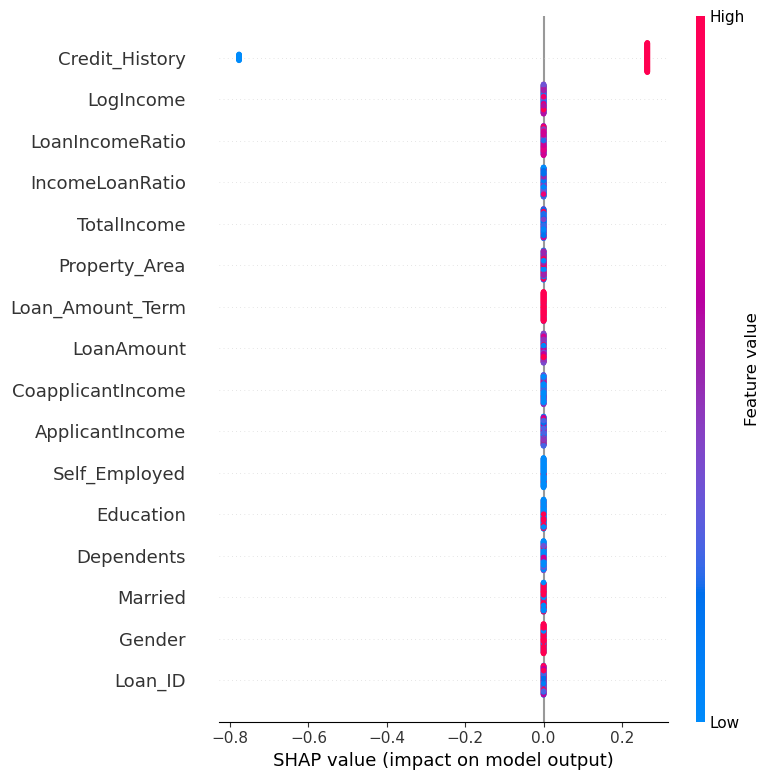

In [68]:
shap.summary_plot(shap_values, x_test, feature_names= x.columns)

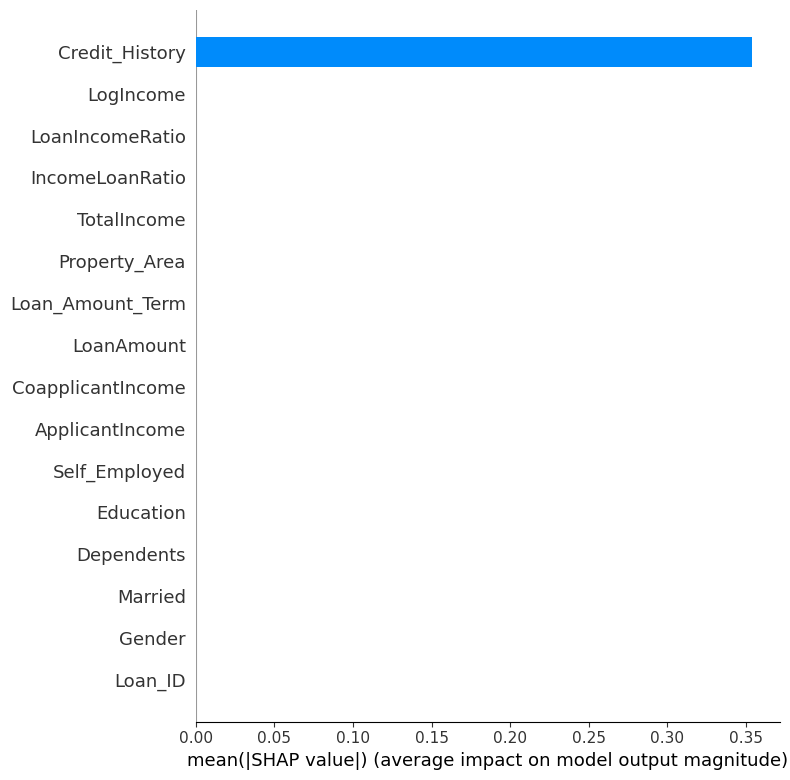

In [69]:
shap.summary_plot(shap_values, x_test, feature_names= x.columns, plot_type= 'bar')

In [71]:
shap.initjs()

In [72]:
shap.force_plot(explainer.expected_value, shap_values[0], x_test[0], feature_names= x.columns)

In [74]:
joblib.dump(best_modell,"best_modell.pkl")

['best_modell.pkl']

In [75]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']